In [0]:
%pip install python-calamine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.2/925.2 kB 22.5 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load the clean dataset we saved in notebook 02
FILE_PATH = "/Volumes/workspace/default/walmart_data/walmart_clean.csv"

df = pd.read_csv(FILE_PATH)
df['event_ts'] = pd.to_datetime(df['event_ts'])

print(f"✅ Clean dataset loaded")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print(f"   Years   : {sorted(df['year'].unique())}")

/home/spark-f6d69d09-1502-4444-884d-75/.ipykernel/2896/command-4982960997226625-250593243:10: DtypeWarning: Columns (15,16,17,19,20,21,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_PATH)


✅ Clean dataset loaded
   Rows    : 355,661
   Columns : 47
   Years   : [np.int64(2024), np.int64(2025)]


# 03 — Exploratory Data Analysis (EDA)

## Goal
Visualise the data to find patterns, trends, and anomalies that answer
our core question: WHERE and WHY is the supply chain underperforming?

## Structure
1. Overall KPI summary
2. On-time performance by region
3. On-time performance by product category
4. Delay distribution
5. Monthly trends
6. Lifecycle stage performance
7. Top exception codes

In [0]:
# WHY: Before any charts, always state your headline numbers.
# These are the KPIs (Key Performance Indicators) — the metrics
# a supply chain manager checks every morning.
# Every chart after this will try to EXPLAIN these numbers.

on_time = df['on_time_flag'].dropna()
delayed = df[df['is_delayed'] == 1]

print("=" * 50)
print("  SUPPLY CHAIN KPI SUMMARY — 2024/2025")
print("=" * 50)
print(f"  Total Events         : {len(df):>10,}")
print(f"  On-Time Rate         : {(on_time == 1).sum() / len(on_time) * 100:>9.1f}%")
print(f"  Late Deliveries      : {(on_time == 0).sum():>10,}")
print(f"  Avg Delay (days)     : {df['delay_days'].mean():>9.2f}")
print(f"  Max Delay (days)     : {df['delay_days'].max():>9.0f}")
print(f"  Anomaly Rate         : {df['anomaly_flag'].mean() * 100:>9.1f}%")
print(f"  Revenue Leakage Rate : {df['revenue_leakage_flag'].mean() * 100:>9.1f}%")
print(f"  Avg Margin           : ${df['margin'].mean():>8.2f}")
print(f"  Avg Margin %         : {df['margin_pct'].mean():>9.1f}%")
print("=" * 50)

  SUPPLY CHAIN KPI SUMMARY — 2024/2025
  Total Events         :    355,661
  On-Time Rate         :      70.7%
  Late Deliveries      :    100,205
  Avg Delay (days)     :      0.75
  Max Delay (days)     :        14
  Anomaly Rate         :      31.2%
  Revenue Leakage Rate :       9.8%
  Avg Margin           : $   40.87
  Avg Margin %         :      42.6%


ON-TIME PERFORMANCE BY REGION
                  total_events  on_time_count  late_count  on_time_rate  avg_delay_days
warehouse_region                                                                       
Central                82245.0        55778.0     23379.0         70.47            0.75
Northeast             100368.0        68289.0     28199.0         70.77            0.75
Southeast              94786.0        64667.0     26382.0         71.02            0.74
West                   78262.0        53081.0     22245.0         70.47            0.77


/home/spark-f6d69d09-1502-4444-884d-75/.ipykernel/2896/command-4982960997226628-2116577802:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_perf = df.groupby('warehouse_region').apply(


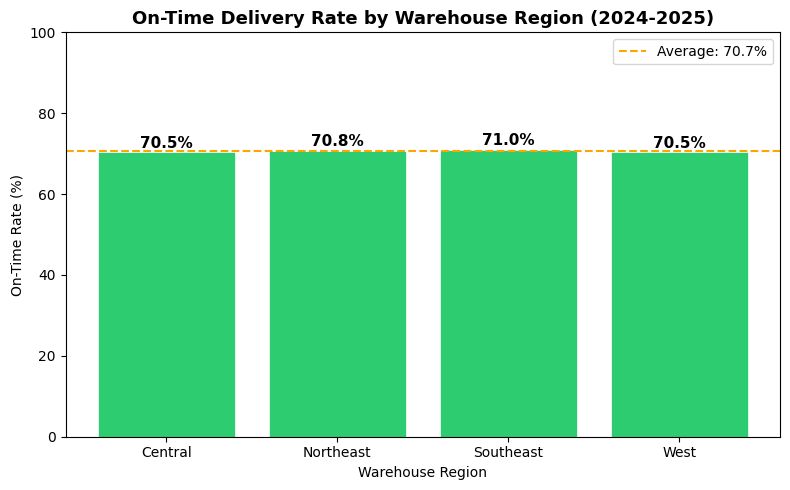

In [0]:
# WHY: Overall numbers hide the real story.
# A 70.7% average could mean all regions are similar,
# OR one region is dragging everyone down.
# We need to break it down to find WHERE the problem is worst.

region_perf = df.groupby('warehouse_region').apply(
    lambda x: pd.Series({
        'total_events': len(x),
        'on_time_count': (x['on_time_flag'] == 1).sum(),
        'late_count': (x['on_time_flag'] == 0).sum(),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100,
        'avg_delay_days': x['delay_days'].mean()
    })
).round(2)

print("ON-TIME PERFORMANCE BY REGION")
print("=" * 55)
print(region_perf.to_string())

# Chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if x >= 70 else '#e74c3c' for x in region_perf['on_time_rate']]
bars = ax.bar(region_perf.index, region_perf['on_time_rate'], color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=region_perf['on_time_rate'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f"Average: {region_perf['on_time_rate'].mean():.1f}%")
ax.set_title('On-Time Delivery Rate by Warehouse Region (2024-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Warehouse Region')
ax.set_ylabel('On-Time Rate (%)')
ax.set_ylim(0, 100)
ax.legend()
for bar, val in zip(bars, region_perf['on_time_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

ON-TIME PERFORMANCE BY PRODUCT CATEGORY
                      total_events  on_time_rate  avg_delay_days  late_count
product_category                                                            
Household Essentials       53744.0         72.13            0.73     14441.0
Electronics               113243.0         71.92            0.71     30902.0
Grocery                   174589.0         71.78            0.74     47289.0
Health & Wellness           1744.0         65.37            1.71       375.0
Apparel                    12341.0         37.27            1.38      7198.0


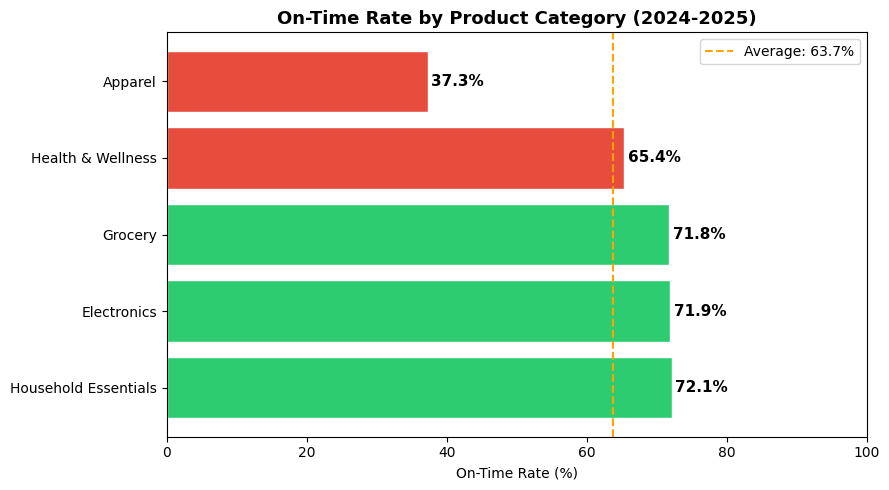

In [0]:
# WHY: Regions showed no difference. Let's check product categories.
# Maybe Electronics (high value, complex shipping) performs worse than Grocery?

cat_perf = df.groupby('product_category').apply(
    lambda x: pd.Series({
        'total_events': len(x),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100,
        'avg_delay_days': x['delay_days'].mean(),
        'late_count': (x['on_time_flag'] == 0).sum()
    }), include_groups=False
).round(2).sort_values('on_time_rate', ascending=False)

print("ON-TIME PERFORMANCE BY PRODUCT CATEGORY")
print("=" * 55)
print(cat_perf.to_string())

# Chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if x >= 70 else '#e74c3c' for x in cat_perf['on_time_rate']]
bars = ax.barh(cat_perf.index, cat_perf['on_time_rate'], color=colors, edgecolor='white')
ax.axvline(x=cat_perf['on_time_rate'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f"Average: {cat_perf['on_time_rate'].mean():.1f}%")
ax.set_title('On-Time Rate by Product Category (2024-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('On-Time Rate (%)')
ax.set_xlim(0, 100)
ax.legend()
for bar, val in zip(bars, cat_perf['on_time_rate']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

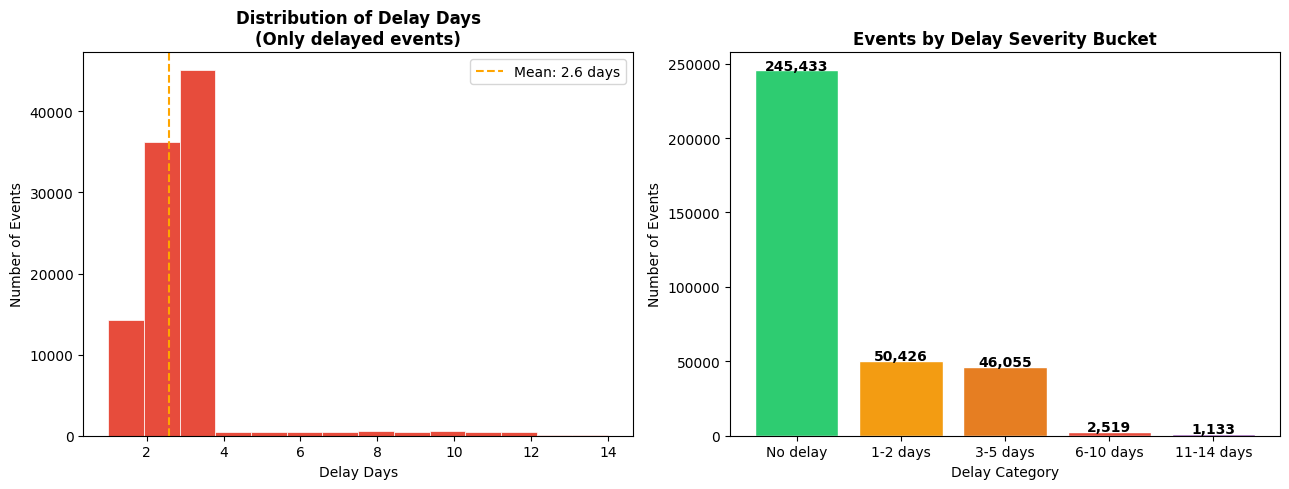


DELAY BUCKET BREAKDOWN
  No delay     245,433  (69.0%)
  1-2 days      50,426  (14.2%)
  3-5 days      46,055  (12.9%)
  6-10 days      2,519  (0.7%)
  11-14 days     1,133  (0.3%)


In [0]:
# WHY: We know the average delay is 0.75 days, but averages are misleading.
# This chart shows the FULL picture — how many events have 0 delay,
# how many have 1 day, 2 days, etc.
# It will confirm our suspicion that most events are fine
# but a small number are severely delayed.

delay_data = df[df['delay_days'] > 0]['delay_days']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left chart — distribution of delay days
axes[0].hist(delay_data, bins=14, color='#e74c3c', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Delay Days\n(Only delayed events)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Delay Days')
axes[0].set_ylabel('Number of Events')
axes[0].axvline(delay_data.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {delay_data.mean():.1f} days')
axes[0].legend()

# Right chart — % of events by delay bucket
buckets = pd.cut(df['delay_days'], bins=[-1, 0, 2, 5, 10, 14],
                 labels=['No delay', '1-2 days', '3-5 days', '6-10 days', '11-14 days'])
bucket_counts = buckets.value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
axes[1].bar(bucket_counts.index, bucket_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Events by Delay Severity Bucket', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Delay Category')
axes[1].set_ylabel('Number of Events')
for i, (val) in enumerate(bucket_counts.values):
    axes[1].text(i, val + 500, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDELAY BUCKET BREAKDOWN")
print("=" * 40)
for bucket, count in bucket_counts.items():
    pct = count / len(df) * 100
    print(f"  {str(bucket):<12} {count:>7,}  ({pct:.1f}%)")

PERFORMANCE BY LIFECYCLE STAGE
                      total_events  on_time_rate  avg_delay_days  anomaly_rate
lifecycle_stage                                                               
ORDERS                     45775.0         90.86            0.27          9.14
FULFILLMENT                79340.0         82.72            0.48         17.28
SHIPMENT                  100828.0         69.95            0.65         30.05
FORWARD_LOGISTICS          51162.0         65.35            0.75         34.65
INVENTORY_MANAGEMENT       30896.0         51.67            1.80         55.58
REVERSE_LOGISTICS          44114.0         44.09            1.34         61.66
SKU_MANAGEMENT              3546.0           NaN            1.99         23.43


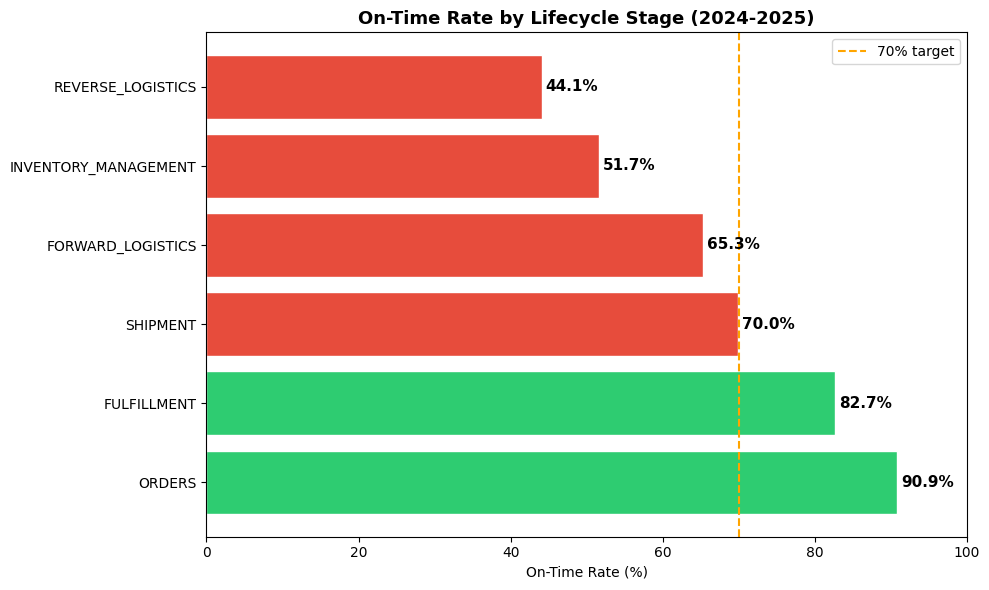

In [0]:
# WHY: Lifecycle stage tells us WHERE in the supply chain journey
# the delays are happening. Is it when suppliers send to DC?
# When DC ships to customer? Or during returns?
# This is crucial for knowing which TEAM to fix first.

stage_perf = df.groupby('lifecycle_stage').apply(
    lambda x: pd.Series({
        'total_events': len(x),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100 if x['on_time_flag'].dropna().shape[0] > 0 else None,
        'avg_delay_days': x['delay_days'].mean(),
        'anomaly_rate': x['anomaly_flag'].mean() * 100
    }), include_groups=False
).round(2).sort_values('on_time_rate', ascending=False)

print("PERFORMANCE BY LIFECYCLE STAGE")
print("=" * 65)
print(stage_perf.to_string())

# Chart
fig, ax = plt.subplots(figsize=(10, 6))
valid = stage_perf.dropna(subset=['on_time_rate'])
colors = ['#2ecc71' if x >= 70 else '#e74c3c' for x in valid['on_time_rate']]
bars = ax.barh(valid.index, valid['on_time_rate'], color=colors, edgecolor='white')
ax.axvline(x=70, color='orange', linestyle='--', linewidth=1.5, label='70% target')
ax.set_title('On-Time Rate by Lifecycle Stage (2024-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('On-Time Rate (%)')
ax.set_xlim(0, 100)
ax.legend()
for bar, val in zip(bars, valid['on_time_rate']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

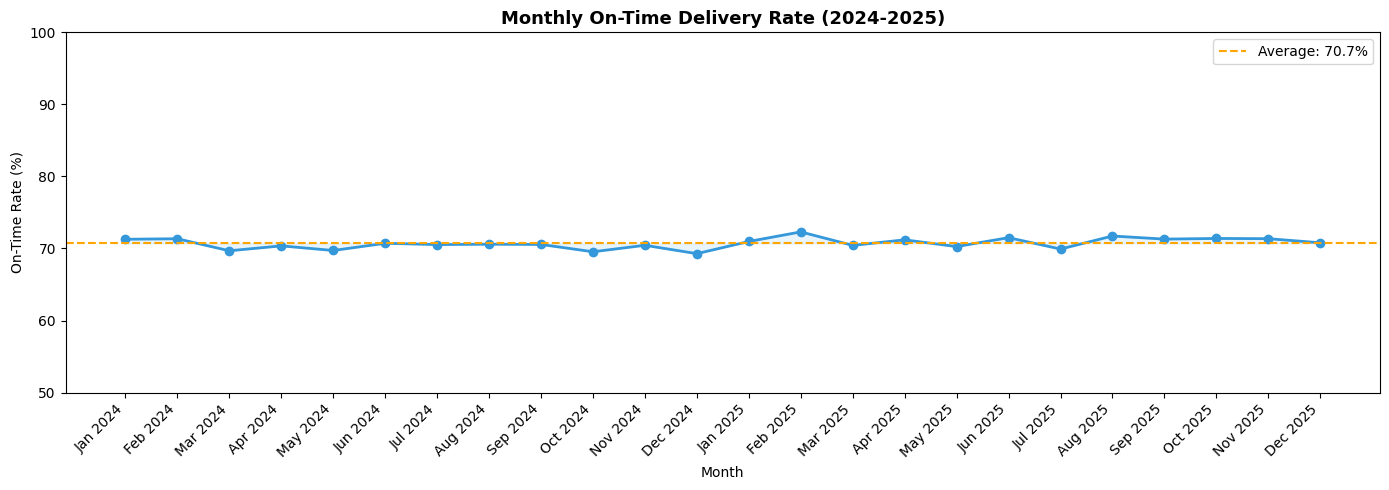


MONTHLY ON-TIME RATE
  Jan 2024      71.3%  ██████████████
  Feb 2024      71.3%  ██████████████
  Mar 2024      69.7%  █████████████
  Apr 2024      70.4%  ██████████████
  May 2024      69.7%  █████████████
  Jun 2024      70.7%  ██████████████
  Jul 2024      70.5%  ██████████████
  Aug 2024      70.6%  ██████████████
  Sep 2024      70.6%  ██████████████
  Oct 2024      69.5%  █████████████
  Nov 2024      70.4%  ██████████████
  Dec 2024      69.3%  █████████████
  Jan 2025      71.0%  ██████████████
  Feb 2025      72.3%  ██████████████
  Mar 2025      70.4%  ██████████████
  Apr 2025      71.2%  ██████████████
  May 2025      70.3%  ██████████████
  Jun 2025      71.5%  ██████████████
  Jul 2025      69.9%  █████████████
  Aug 2025      71.7%  ██████████████
  Sep 2025      71.3%  ██████████████
  Oct 2025      71.4%  ██████████████
  Nov 2025      71.4%  ██████████████
  Dec 2025      70.8%  ██████████████


In [0]:
# WHY: Are things getting better or worse over time?
# A monthly trend shows whether any improvements are happening
# or whether the problem is growing.

monthly = df.groupby(['year', 'month', 'month_name']).apply(
    lambda x: pd.Series({
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100,
        'total_events': len(x),
        'avg_delay': x['delay_days'].mean()
    }), include_groups=False
).reset_index().round(2)

monthly['period'] = monthly['month_name'] + ' ' + monthly['year'].astype(str)
monthly = monthly.sort_values(['year', 'month'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['period'], monthly['on_time_rate'],
        marker='o', linewidth=2, color='#3498db', markersize=6)
ax.axhline(y=monthly['on_time_rate'].mean(), color='orange',
           linestyle='--', linewidth=1.5,
           label=f"Average: {monthly['on_time_rate'].mean():.1f}%")
ax.fill_between(range(len(monthly)), monthly['on_time_rate'],
                monthly['on_time_rate'].mean(),
                alpha=0.1, color='#3498db')
ax.set_title('Monthly On-Time Delivery Rate (2024-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('On-Time Rate (%)')
ax.set_ylim(50, 100)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['period'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print("\nMONTHLY ON-TIME RATE")
print("=" * 40)
for _, row in monthly.iterrows():
    bar = '█' * int(row['on_time_rate'] / 5)
    print(f"  {row['period']:<12} {row['on_time_rate']:>5.1f}%  {bar}")

TOP EXCEPTION CODES
                     count  avg_delay  revenue_leakage  customer_impact  pct_of_exceptions  pct_of_total
exception_code                                                                                          
BACKORDER            25071       3.00              0.0             55.0               22.6           7.0
SALE_DISPUTE         16214       2.00              1.0             88.0               14.6           4.6
DELIVERY_EXCEPTION   13318       1.00              0.0             50.0               12.0           3.7
STORE_STOCKOUT       12452       2.00              0.0             58.0               11.2           3.5
DAMAGED_IN_TRANSIT   10622       3.00              1.0             82.0                9.6           3.0
LOST_IN_TRANSIT       7985       3.00              1.0             80.0                7.2           2.2
SPLIT_DELAY           6690       2.00              0.0             48.0                6.0           1.9
CYCLE_COUNT_VAR       4337        N

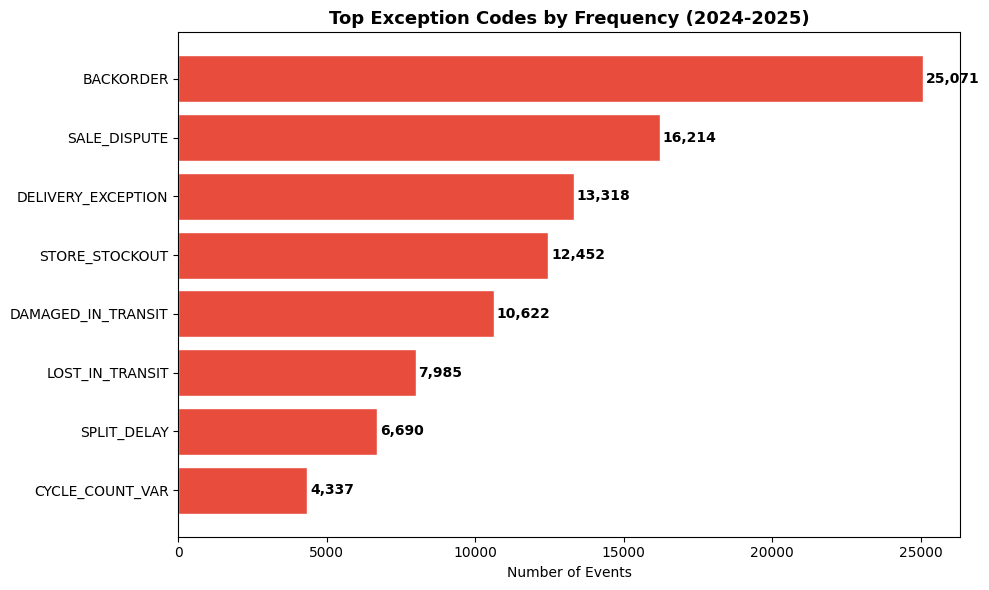

In [0]:
# WHY: Exception codes tell us the specific failure modes.
# These are the actual reasons things go wrong.
# Ranking them by frequency tells us where to focus improvement efforts first.
# Fix the top 3 exception codes and you solve the majority of problems.

exceptions = df[df['exception_code'].notna()].copy()

exc_summary = exceptions.groupby('exception_code').agg(
    count=('exception_code', 'count'),
    avg_delay=('delay_days', 'mean'),
    revenue_leakage=('revenue_leakage_flag', 'mean'),
    customer_impact=('customer_impact_score', 'mean')
).round(2).sort_values('count', ascending=False)

exc_summary['pct_of_exceptions'] = (exc_summary['count'] / len(exceptions) * 100).round(1)
exc_summary['pct_of_total'] = (exc_summary['count'] / len(df) * 100).round(1)

print("TOP EXCEPTION CODES")
print("=" * 75)
print(exc_summary.to_string())

# Chart
fig, ax = plt.subplots(figsize=(10, 6))
top_exc = exc_summary.head(8)
bars = ax.barh(top_exc.index[::-1], top_exc['count'][::-1], color='#e74c3c', edgecolor='white')
ax.set_title('Top Exception Codes by Frequency (2024-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Events')
for bar, val in zip(bars, top_exc['count'][::-1]):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

ON-TIME RATE BY CHANNEL PATH
                                   total_events  on_time_rate  avg_delay_days
channel_path                                                                 
DC>STORE                                 5036.0        100.00            0.00
SUPPLIER>DC>SHIP_TO_HOME>CUSTOMER      279434.0         71.41            0.68
SUPPLIER>DC>STORE>CUSTOMER              40179.0         69.01            0.62
SUPPLIER>DC                             17371.0         54.79            2.17
DC                                       7233.0           NaN             NaN
SKU_MASTER                               3546.0           NaN            1.99
STORE>DC                                 2862.0           NaN             NaN


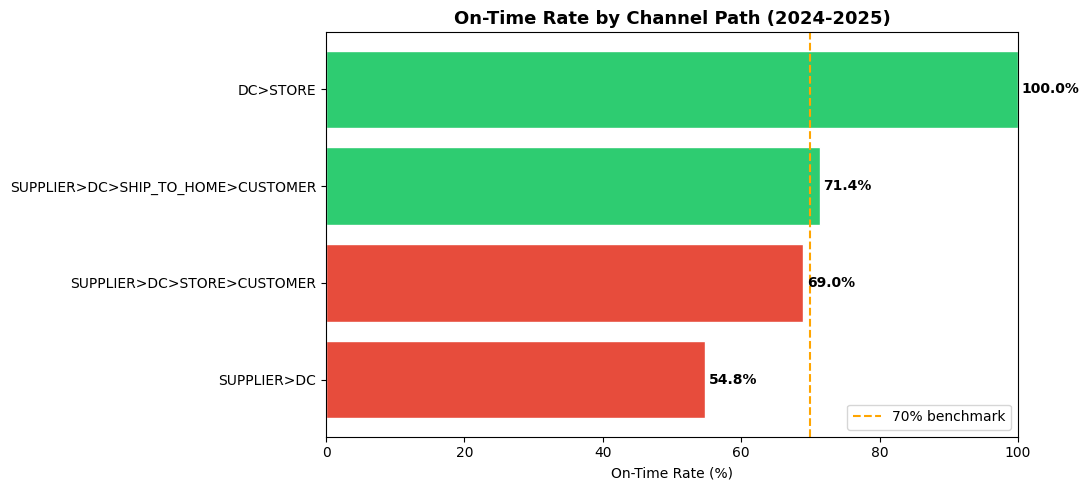

In [0]:
# WHY: Channel path shows the ROUTE a product takes.
# e.g. SUPPLIER>DC>SHIP_TO_HOME>CUSTOMER is the e-commerce route.
# Different routes have different complexity levels —
# more stops = more chances for delays.

channel_perf = df.groupby('channel_path').apply(
    lambda x: pd.Series({
        'total_events': len(x),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100 if x['on_time_flag'].dropna().shape[0] > 0 else None,
        'avg_delay_days': x['delay_days'].mean(),
    }), include_groups=False
).round(2).sort_values('on_time_rate', ascending=False)

print("ON-TIME RATE BY CHANNEL PATH")
print("=" * 70)
print(channel_perf.to_string())

# Chart
fig, ax = plt.subplots(figsize=(11, 5))
valid = channel_perf.dropna(subset=['on_time_rate'])
colors = ['#2ecc71' if x >= 70 else '#e74c3c' for x in valid['on_time_rate']]
bars = ax.barh(valid.index[::-1], valid['on_time_rate'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(x=70, color='orange', linestyle='--', linewidth=1.5, label='70% benchmark')
ax.set_title('On-Time Rate by Channel Path (2024-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('On-Time Rate (%)')
ax.set_xlim(0, 100)
ax.legend()
for bar, val in zip(bars, valid['on_time_rate'][::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [0]:
# WHY: Now we know the supplier-to-DC path is the weakest link.
# Let's identify WHICH suppliers are causing the most delays.
# This gives management a specific list of suppliers to address.

supplier_perf = df.groupby('supplier_name').apply(
    lambda x: pd.Series({
        'total_events': len(x),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100 if x['on_time_flag'].dropna().shape[0] > 0 else None,
        'avg_delay_days': x['delay_days'].mean(),
        'anomaly_rate': x['anomaly_flag'].mean() * 100,
        'revenue_leakage_rate': x['revenue_leakage_flag'].mean() * 100
    }), include_groups=False
).round(2).sort_values('on_time_rate', ascending=True)

print("SUPPLIER PERFORMANCE — RANKED WORST TO BEST")
print("=" * 75)
print(supplier_perf.to_string())

SUPPLIER PERFORMANCE — RANKED WORST TO BEST
                        total_events  on_time_rate  avg_delay_days  anomaly_rate  revenue_leakage_rate
supplier_name                                                                                         
Walmart Private Label       187417.0         69.78            0.78         32.47                  9.21
Fresh Produce Supplier       55001.0         71.28            0.75         30.52                 10.73
Apple Inc.                   29469.0         71.77            0.71         29.78                 10.46
Samsung Electronics          44057.0         71.88            0.71         29.53                 10.22
HP Inc.                      39717.0         72.08            0.71         29.45                 10.26


In [0]:
# WHY: Revenue leakage = money lost. 
# We know 9.8% of events have leakage.
# Now let's find WHERE that leakage is concentrated —
# which categories, lifecycle stages, and exception types cost the most.

print("REVENUE LEAKAGE ANALYSIS")
print("=" * 55)

# Total leakage events
leakage = df[df['revenue_leakage_flag'] == 1]
print(f"\n  Total leakage events : {len(leakage):,}")
print(f"  As % of all events   : {len(leakage)/len(df)*100:.1f}%")

# By product category
print(f"\n  BY PRODUCT CATEGORY:")
print(f"  {'-'*50}")
cat_leak = df.groupby('product_category').apply(
    lambda x: pd.Series({
        'leakage_events': x['revenue_leakage_flag'].sum(),
        'leakage_rate': x['revenue_leakage_flag'].mean() * 100
    }), include_groups=False
).round(2).sort_values('leakage_rate', ascending=False)
print(cat_leak.to_string())

# By lifecycle stage
print(f"\n  BY LIFECYCLE STAGE:")
print(f"  {'-'*50}")
stage_leak = df.groupby('lifecycle_stage').apply(
    lambda x: pd.Series({
        'leakage_events': x['revenue_leakage_flag'].sum(),
        'leakage_rate': x['revenue_leakage_flag'].mean() * 100
    }), include_groups=False
).round(2).sort_values('leakage_rate', ascending=False)
print(stage_leak.to_string())

# By exception code (only where leakage = 1)
print(f"\n  EXCEPTION CODES CAUSING 100% LEAKAGE:")
print(f"  {'-'*50}")
exc_leak = df[df['revenue_leakage_flag'] == 1]['exception_code'].value_counts()
print(exc_leak.to_string())

REVENUE LEAKAGE ANALYSIS

  Total leakage events : 34,821
  As % of all events   : 9.8%

  BY PRODUCT CATEGORY:
  --------------------------------------------------
                      leakage_events  leakage_rate
product_category                                  
Electronics                  11658.0         10.29
Household Essentials          5476.0         10.19
Grocery                      17687.0         10.13
Apparel                          0.0          0.00
Health & Wellness                0.0          0.00

  BY LIFECYCLE STAGE:
  --------------------------------------------------
                      leakage_events  leakage_rate
lifecycle_stage                                   
REVERSE_LOGISTICS            21444.0         48.61
FORWARD_LOGISTICS             5250.0         10.26
SHIPMENT                      6127.0          6.08
FULFILLMENT                   2000.0          2.52
INVENTORY_MANAGEMENT             0.0          0.00
ORDERS                           0.0         

ANOMALY DISTRIBUTION ANALYSIS

  ANOMALY RATE BY LIFECYCLE STAGE:
  --------------------------------------------------
                       total  anomalies  anomaly_rate
lifecycle_stage                                      
REVERSE_LOGISTICS      44114      27202         61.66
INVENTORY_MANAGEMENT   30896      17172         55.58
FORWARD_LOGISTICS      51162      17728         34.65
SHIPMENT              100828      30303         30.05
SKU_MANAGEMENT          3546        831         23.43
FULFILLMENT            79340      13712         17.28
ORDERS                 45775       4183          9.14

  ANOMALY RATE BY PRODUCT CATEGORY:
  --------------------------------------------------
                       total  anomalies  anomaly_rate
product_category                                     
Apparel                12341       7894         63.97
Health & Wellness       1744        905         51.89
Grocery               174589      52849         30.27
Household Essentials   53744      1

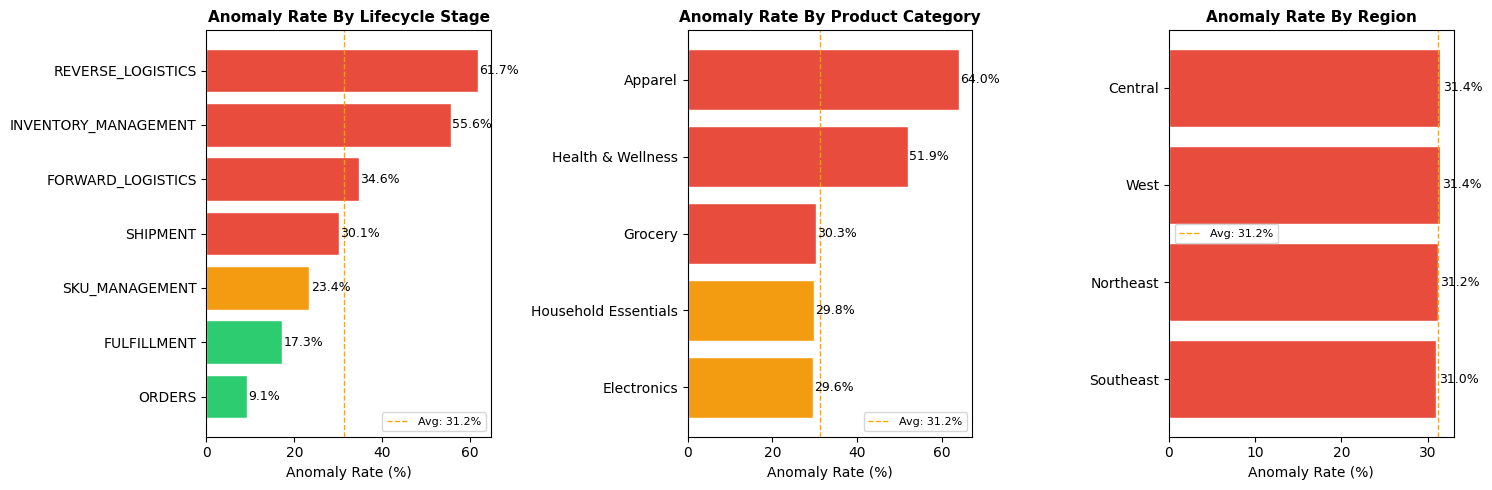

In [0]:
# WHY: 31.2% of events are flagged as anomalies.
# We need to understand WHERE anomalies cluster.
# High anomaly rates in specific areas indicate systemic instability.

print("ANOMALY DISTRIBUTION ANALYSIS")
print("=" * 55)

# By lifecycle stage
print("\n  ANOMALY RATE BY LIFECYCLE STAGE:")
print(f"  {'-'*50}")
stage_anom = df.groupby('lifecycle_stage')['anomaly_flag'].agg(
    total='count',
    anomalies='sum',
    anomaly_rate=lambda x: x.mean() * 100
).round(2).sort_values('anomaly_rate', ascending=False)
print(stage_anom.to_string())

# By product category
print("\n  ANOMALY RATE BY PRODUCT CATEGORY:")
print(f"  {'-'*50}")
cat_anom = df.groupby('product_category')['anomaly_flag'].agg(
    total='count',
    anomalies='sum',
    anomaly_rate=lambda x: x.mean() * 100
).round(2).sort_values('anomaly_rate', ascending=False)
print(cat_anom.to_string())

# By warehouse region
print("\n  ANOMALY RATE BY WAREHOUSE REGION:")
print(f"  {'-'*50}")
reg_anom = df.groupby('warehouse_region')['anomaly_flag'].agg(
    total='count',
    anomalies='sum',
    anomaly_rate=lambda x: x.mean() * 100
).round(2).sort_values('anomaly_rate', ascending=False)
print(reg_anom.to_string())

# Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (data, title) in zip(axes, [
    (stage_anom, 'By Lifecycle Stage'),
    (cat_anom, 'By Product Category'),
    (reg_anom, 'By Region')
]):
    colors = ['#e74c3c' if x >= 30 else '#f39c12' if x >= 20 else '#2ecc71'
              for x in data['anomaly_rate']]
    bars = ax.barh(data.index[::-1], data['anomaly_rate'][::-1],
                   color=colors[::-1], edgecolor='white')
    ax.axvline(x=31.2, color='orange', linestyle='--', linewidth=1,
               label='Avg: 31.2%')
    ax.set_title(f'Anomaly Rate {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Anomaly Rate (%)')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, data['anomaly_rate'][::-1]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

BRAND PERFORMANCE — RANKED WORST TO BEST
               total_events  on_time_rate  avg_delay_days  anomaly_rate  revenue_leakage_rate
brand                                                                                        
Wonder Nation        6199.0         36.94            1.39         64.32                  0.00
Faded Glory          6142.0         37.60            1.37         63.61                  0.00
Equate               1744.0         65.37            1.71         51.89                  0.00
Fresh Produce       55001.0         71.28            0.75         30.52                 10.73
Apple               29469.0         71.77            0.71         29.78                 10.46
Samsung             44057.0         71.88            0.71         29.53                 10.22
Great Value        173332.0         72.05            0.73         30.04                  9.96
HP                  39717.0         72.08            0.71         29.45                 10.26


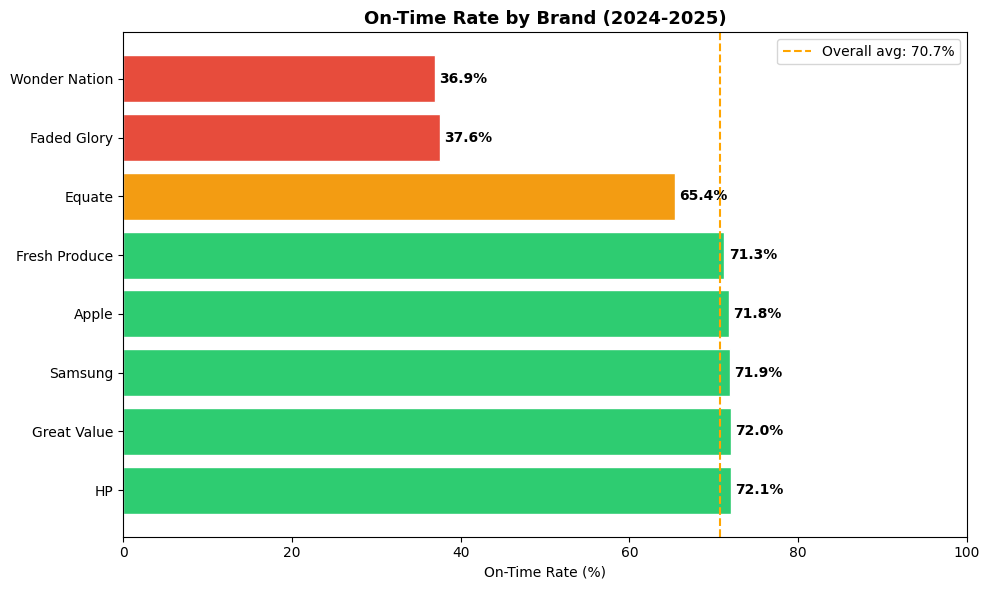

In [0]:
# WHY: Brand is closely linked to product category but gives us
# a more specific view. Great Value = Grocery (private label),
# HP/Samsung/Apple = Electronics etc.
# This confirms whether category findings hold at brand level too.

brand_perf = df.groupby('brand').apply(
    lambda x: pd.Series({
        'total_events': len(x),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100 if x['on_time_flag'].dropna().shape[0] > 0 else None,
        'avg_delay_days': x['delay_days'].mean(),
        'anomaly_rate': x['anomaly_flag'].mean() * 100,
        'revenue_leakage_rate': x['revenue_leakage_flag'].mean() * 100
    }), include_groups=False
).round(2).sort_values('on_time_rate', ascending=True)

print("BRAND PERFORMANCE — RANKED WORST TO BEST")
print("=" * 80)
print(brand_perf.to_string())

# Chart
fig, ax = plt.subplots(figsize=(10, 6))
valid = brand_perf.dropna(subset=['on_time_rate'])
colors = ['#e74c3c' if x < 50 else '#f39c12' if x < 70 else '#2ecc71'
          for x in valid['on_time_rate']]
bars = ax.barh(valid.index[::-1], valid['on_time_rate'][::-1],
               color=colors[::-1], edgecolor='white')
ax.axvline(x=70.7, color='orange', linestyle='--',
           linewidth=1.5, label='Overall avg: 70.7%')
ax.set_title('On-Time Rate by Brand (2024-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('On-Time Rate (%)')
ax.set_xlim(0, 100)
ax.legend()
for bar, val in zip(bars, valid['on_time_rate'][::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()